# End-to-End Table Extraction Pipeline

**Paper:** CTT Lancet 2024 &nbsp;|&nbsp; **Pages:** 7, 9

Two Gemini agents in sequence:
1. **Detection Agent** — scans PDF page, identifies tables, generates bounding boxes + descriptions + extraction instructions
2. **Fixer Agent** — receives UniTable-extracted HTML, corrects OCR errors cell by cell

```
PDF → render page image
    → Gemini Detection Agent  (classify_page)  →  bbox, label, type, description, instruction
    → crop to bbox
    → UniTable  (structure extraction)
    → Gemini Fixer Agent  (hybrid_extract)  →  corrected HTML
    → HTML → DataFrame → CSV
    → compare_tables  vs ground truth
```

In [38]:
import sys
import re
import io
import base64
import importlib.util
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display

Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check for large PDF renders

project_root = Path.cwd().parent
huma_root    = project_root / "Huma-Huma"

for p in [project_root, huma_root, huma_root / "unitable"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from shared.client import client, DEFAULT_MODEL
from shared.pdf import render_pages
from shared.eval import compare_tables, print_accuracy_summary
from agents.router.classify import classify_page
from agents.router.schema import BoundingBox

print(f"Model: {DEFAULT_MODEL}")
print("Imports OK")

Model: gemini-3-flash-preview
Imports OK


In [39]:
PAPER_ID   = "20-702S025_Lipitor_statr"
PAGES      = [13]
PDF_PATH   = str(project_root / "papers" / PAPER_ID / "paper.pdf")
OUTPUT_DIR = project_root / "output" / PAPER_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GT_FILES = {
    13: project_root / "papers" / PAPER_ID / "ground_truth" / "page-13_fig6_demographics.csv",
}

FIXER_PROMPT = """You are a meticulous data verification expert for scientific HTML tables.

You will receive a table image and its HTML extracted by an OCR model. The table structure
(rows, columns, colspan, rowspan) is 100% correct. Your only task is to fix cell text that
doesn't match the image.

Pay close attention to:
1. Mathematical and scientific symbols: ±, <, >, ≤, ≥, Greek letters (α, β, γ, δ)
2. Numeric precision: every digit, decimal points, distinguish 0/O, 1/l/I
3. Case sensitivity: exact capitalization of headers and data
4. Subscripts/superscripts: chemical formulas, significance markers
5. Special characters: dashes vs hyphens, degree symbols, percent signs

Strict constraints:
- Do NOT modify HTML structure, <tr>, <td>, <th>, colspan, rowspan
- Do NOT add or remove cells
- Return ONLY the corrected HTML — no markdown fences, no explanations
- If no corrections are needed, respond with exactly: NO_CHANGES
"""

print(f"Paper:  {PAPER_ID}")
print(f"Pages:  {PAGES}")
print(f"Output: {OUTPUT_DIR}")

Paper:  20-702S025_Lipitor_statr
Pages:  [13]
Output: /Users/roshgill/Desktop/HumaAI/output/20-702S025_Lipitor_statr


In [40]:
Image.MAX_IMAGE_PIXELS = None  # must be set before any crop/load on large PDF renders

# ── Load UniTable ────────────────────────────────────────────────────────────
spec = importlib.util.spec_from_file_location(
    "unitable_extractor",
    str(huma_root / "table_extraction" / "unitable.py"),
)
unitable_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unitable_mod)
extractor = unitable_mod.UniTableExtractor()
print(f"UniTable device: {extractor.device}")


# ── Helpers ──────────────────────────────────────────────────────────────────
def crop_bbox(image: Image.Image, bbox: BoundingBox) -> Image.Image:
    """Crop image to bounding box expressed as percentage coordinates."""
    w, h = image.size
    return image.crop((
        bbox.x_min / 100 * w,
        bbox.y_min / 100 * h,
        bbox.x_max / 100 * w,
        bbox.y_max / 100 * h,
    ))


def html_to_df(html: str) -> pd.DataFrame | None:
    """Parse HTML table to DataFrame."""
    try:
        tables = pd.read_html(html)
        return tables[0] if tables else None
    except Exception:
        return None


def hybrid_extract(image: Image.Image, unitable_html: str) -> str:
    """Gemini Fixer Agent: correct OCR errors in UniTable HTML.

    Returns corrected HTML, original HTML if NO_CHANGES, or '' on failure.
    """
    if not unitable_html:
        return ""
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    response = client.models.generate_content(
        model=DEFAULT_MODEL,
        contents=[
            {"inline_data": {"mime_type": "image/png", "data": base64.b64encode(buf.getvalue()).decode()}},
            f"Here is the UniTable HTML to correct:\n\n{unitable_html}",
        ],
        config={"system_instruction": FIXER_PROMPT, "temperature": 0.0},
    )
    text = response.text.strip()
    if text == "NO_CHANGES":
        return unitable_html
    text = re.sub(r'^```html\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text


print("crop_bbox(), html_to_df(), hybrid_extract() ready")

Loading UniTable models...
  ✓ Structure model loaded
  ✓ Bbox model loaded
  ✓ Content model loaded
UniTable ready for inference!
UniTable device: mps
crop_bbox(), html_to_df(), hybrid_extract() ready


Rendering pages [13] from PDF...


Python(70148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(70149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(70150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


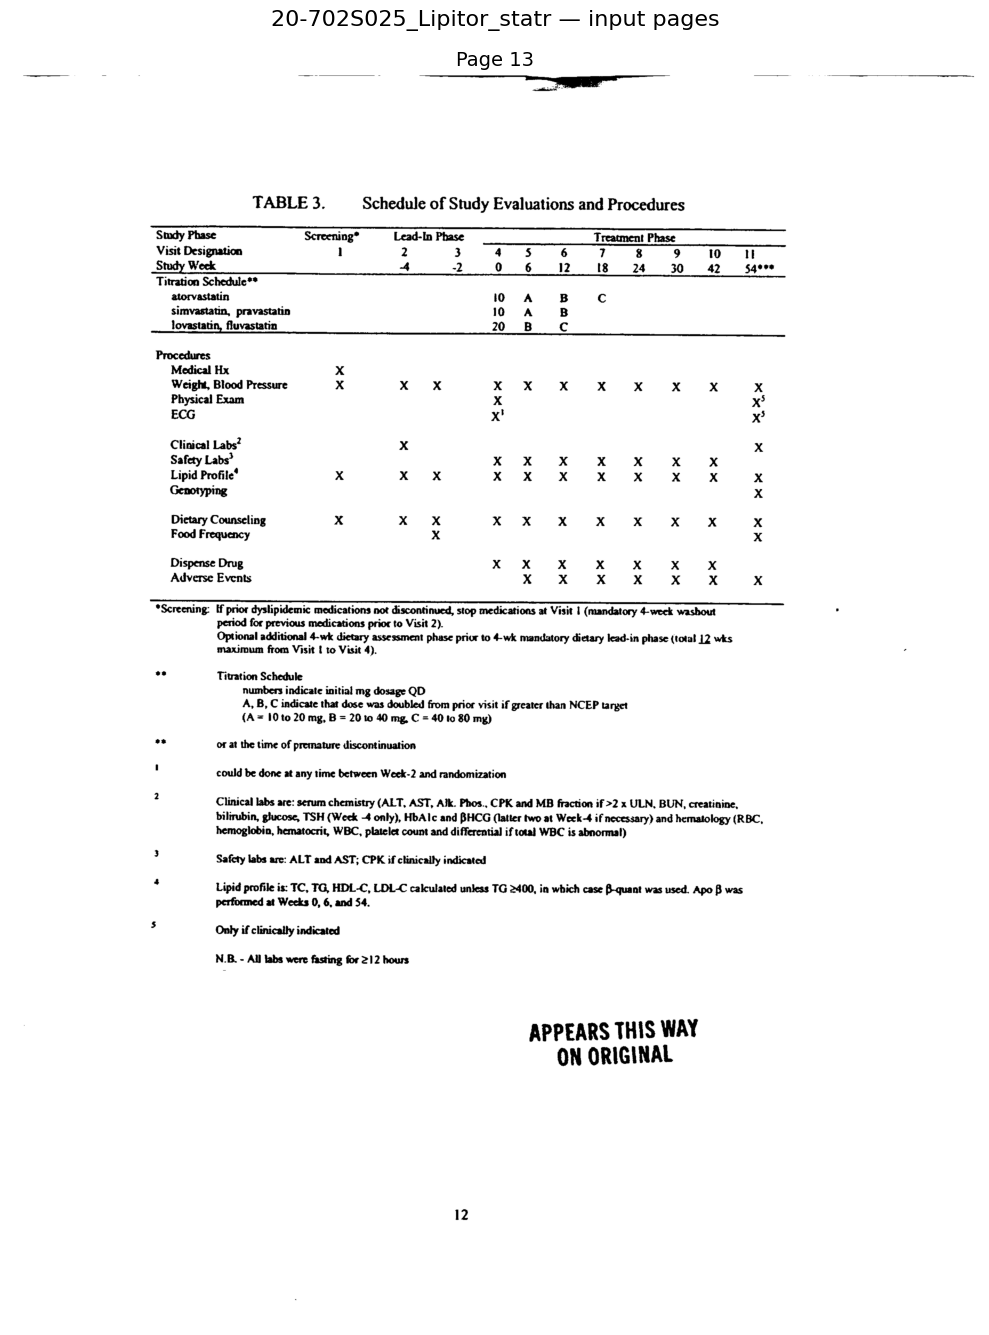

Rendered 1 pages


In [41]:
print(f"Rendering pages {PAGES} from PDF...")
page_images = render_pages(PDF_PATH, PAGES)

fig, axes = plt.subplots(1, len(PAGES), figsize=(10 * len(PAGES), 14))
if len(PAGES) == 1:
    axes = [axes]
for ax, page in zip(axes, PAGES):
    ax.imshow(page_images[page])
    ax.set_title(f"Page {page}", fontsize=14)
    ax.axis("off")
plt.suptitle(f"{PAPER_ID} — input pages", fontsize=16)
plt.tight_layout()
plt.show()
print(f"Rendered {len(page_images)} pages")

In [42]:
print("Running Gemini Detection Agent...\n")
detections: dict[int, list] = {}

for page in PAGES:
    print(f"  Page {page}: ", end="", flush=True)
    result = classify_page(client, DEFAULT_MODEL, page_images[page])
    detections[page] = result.tables
    print(f"{len(result.tables)} table(s) detected")

    rows = []
    for t in result.tables:
        bbox_str = (
            f"({t.bbox.x_min:.1f}, {t.bbox.y_min:.1f}) → ({t.bbox.x_max:.1f}, {t.bbox.y_max:.1f})"
            if t.bbox else "None"
        )
        rows.append({
            "Label":       t.label,
            "Type":        t.type,
            "Description": t.description,
            "BBox (%)": bbox_str,
        })
    display(
        pd.DataFrame(rows)
        .style
        .set_caption(f"Page {page} — Gemini Detection Agent output")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )
    print()

Running Gemini Detection Agent...

  Page 13: 1 table(s) detected


,Label,Type,Description,BBox (%)
0,Table 3,general_table,"A schedule of study evaluations and procedures across different study phases and weeks, including titration schedules and various medical procedures.","(14.0, 9.0) → (80.3, 72.3)"


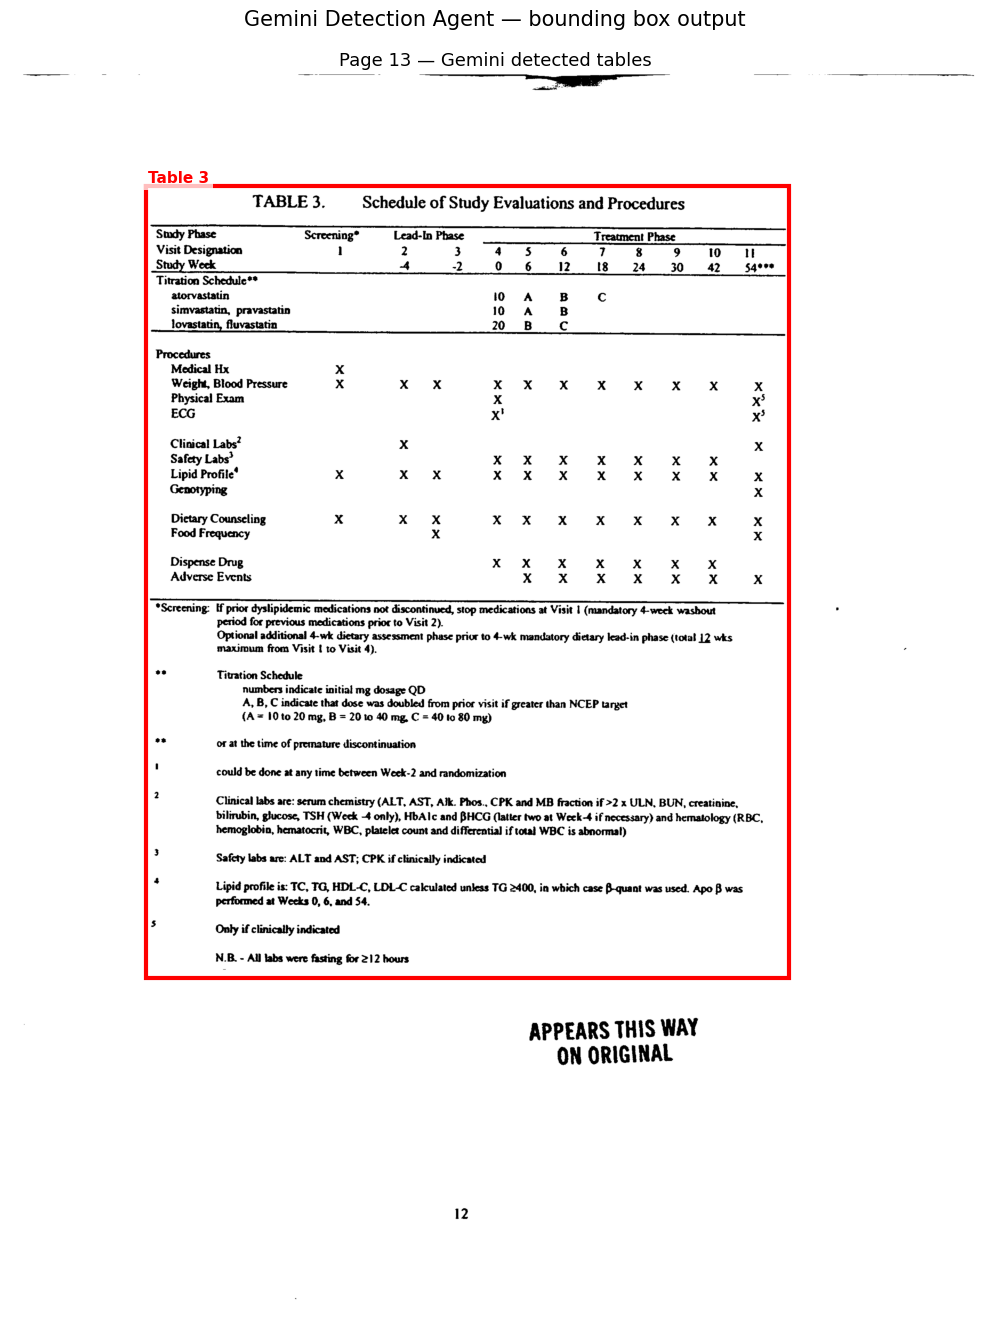

In [43]:
fig, axes = plt.subplots(1, len(PAGES), figsize=(10 * len(PAGES), 14))
if len(PAGES) == 1:
    axes = [axes]

for ax, page in zip(axes, PAGES):
    img = page_images[page]
    w, h = img.size
    ax.imshow(img)
    ax.set_title(f"Page {page} — Gemini detected tables", fontsize=13)
    ax.axis("off")

    for t in detections[page]:
        if not t.bbox:
            continue
        x0 = t.bbox.x_min / 100 * w
        y0 = t.bbox.y_min / 100 * h
        bw = (t.bbox.x_max - t.bbox.x_min) / 100 * w
        bh = (t.bbox.y_max - t.bbox.y_min) / 100 * h
        rect = patches.Rectangle(
            (x0, y0), bw, bh,
            linewidth=3, edgecolor="red", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x0 + 6, y0 - 12, t.label,
            color="red", fontsize=11, fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=3),
        )

plt.suptitle("Gemini Detection Agent — bounding box output", fontsize=15)
plt.tight_layout()
plt.show()


  Table 3  (page 13, type: general_table)
  A schedule of study evaluations and procedures across different study phases and weeks, including titration schedules and various medical procedures.


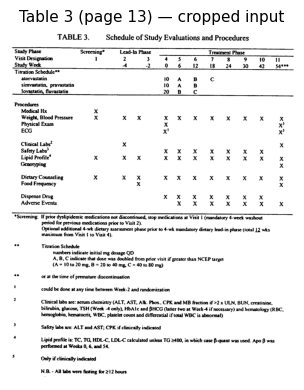

  [1/2] UniTable structure extraction ... 332.7s
  [2/2] Gemini Fixer Agent ... 165.1s
  Extracted: 0 rows × 0 columns


In [44]:
import time

extracted: dict[str, dict] = {}  # key → {page, table, html, df}

for page in PAGES:
    for t in detections[page]:
        if not t.bbox:
            print(f"  Page {page} / {t.label}: no bbox — skipping")
            continue

        key = f"p{page}_{t.label.lower().replace(' ', '_')}"
        print(f"\n{'='*64}")
        print(f"  {t.label}  (page {page}, type: {t.type})")
        print(f"  {t.description}")
        print(f"{'='*64}")

        crop = crop_bbox(page_images[page], t.bbox)

        fig, ax = plt.subplots(figsize=(11, 4))
        ax.imshow(crop)
        ax.set_title(f"{t.label} (page {page}) — cropped input", fontsize=11)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        print(f"  [1/2] UniTable structure extraction ... ", end="", flush=True)
        t0 = time.time()
        ut_html = extractor.extract_html(crop)
        print(f"{time.time() - t0:.1f}s")

        print(f"  [2/2] Gemini Fixer Agent ... ", end="", flush=True)
        t0 = time.time()
        final_html = hybrid_extract(crop, ut_html)
        print(f"{time.time() - t0:.1f}s")

        df = html_to_df(final_html)
        extracted[key] = {"page": page, "table": t, "html": final_html, "df": df}
        rows_n = len(df) if df is not None else 0
        cols_n = len(df.columns) if df is not None else 0
        print(f"  Extracted: {rows_n} rows × {cols_n} columns")

In [45]:
for key, item in extracted.items():
    df = item["df"]
    if df is None:
        print(f"{key}: could not parse HTML to DataFrame")
        continue
    display(
        df.style
        .set_caption(f"{item['table'].label}  (page {item['page']}) — extracted table")
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#e8f0fe"), ("font-weight", "bold")]},
        ])
    )
    print()

p13_table_3: could not parse HTML to DataFrame


In [46]:
saved_paths = {}
for key, item in extracted.items():
    df = item["df"]
    if df is None:
        continue
    csv_path = OUTPUT_DIR / f"{key}.csv"
    df.to_csv(csv_path, index=False)
    saved_paths[key] = csv_path
    print(f"  Saved: {csv_path}")

print(f"\n{len(saved_paths)} CSV(s) written to {OUTPUT_DIR}")


0 CSV(s) written to /Users/roshgill/Desktop/HumaAI/output/20-702S025_Lipitor_statr


In [47]:
comparison_results = {}

for page in PAGES:
    gt_path = GT_FILES.get(page)
    if not gt_path or not gt_path.exists():
        print(f"  Page {page}: ground truth file not found at {gt_path}")
        continue

    df_gt = pd.read_csv(gt_path)

    # Find the first extracted table for this page with a valid DataFrame
    page_items = [(k, v) for k, v in extracted.items() if v["page"] == page and v["df"] is not None]
    if not page_items:
        print(f"  Page {page}: no extracted table available")
        continue

    key, item = page_items[0]
    df_pred = item["df"]

    print(f"\nPage {page}: comparing '{item['table'].label}' vs ground truth ({gt_path.name})")
    print(f"  Ground truth: {len(df_gt)} rows × {len(df_gt.columns)} cols")
    print(f"  Extracted:    {len(df_pred)} rows × {len(df_pred.columns)} cols")

    result = compare_tables(df_gt, df_pred)
    comparison_results[key] = result

  Page 13: no extracted table available


In [48]:
for key, result in comparison_results.items():
    item = extracted[key]
    print(f"\n{'='*64}")
    print(f"  {item['table'].label}  (page {item['page']})")
    print(f"{'='*64}")
    print_accuracy_summary(result)

In [49]:
rows = []
for key, result in comparison_results.items():
    item = extracted[key]
    rows.append({
        "Page":           item["page"],
        "Table":          item["table"].label,
        "Type":           item["table"].type,
        "GT Rows":        result["truth_count"],
        "Extracted Rows": result["extracted_count"],
        "Cell Accuracy":  f"{result['cell_accuracy']:.1%}",
        "Row Match":      f"{result['row_match']:.1%}",
    })

df_summary = pd.DataFrame(rows)
display(
    df_summary.style
    .set_caption("End-to-End Pipeline Results")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background-color", "#e8f0fe"), ("font-weight", "bold")]},
    ])
)

if comparison_results:
    overall = sum(r["cell_accuracy"] for r in comparison_results.values()) / len(comparison_results)
    print(f"\nOverall cell accuracy: {overall:.1%}")
print(f"CSVs saved to: {OUTPUT_DIR}")

CSVs saved to: /Users/roshgill/Desktop/HumaAI/output/20-702S025_Lipitor_statr
